In [3]:
# 파이썬 유틸리티 함수 정의
import matplotlib.pyplot as plt
import numpy as np
from skimage.io import imread
from skimage.color import rgb2gray, rgba2rgb

def plot_image(image, title=''):
    plt.imshow(image)
    plt.axis('off')
    plt.title(title, size=20)

<Figure size 640x480 with 0 Axes>

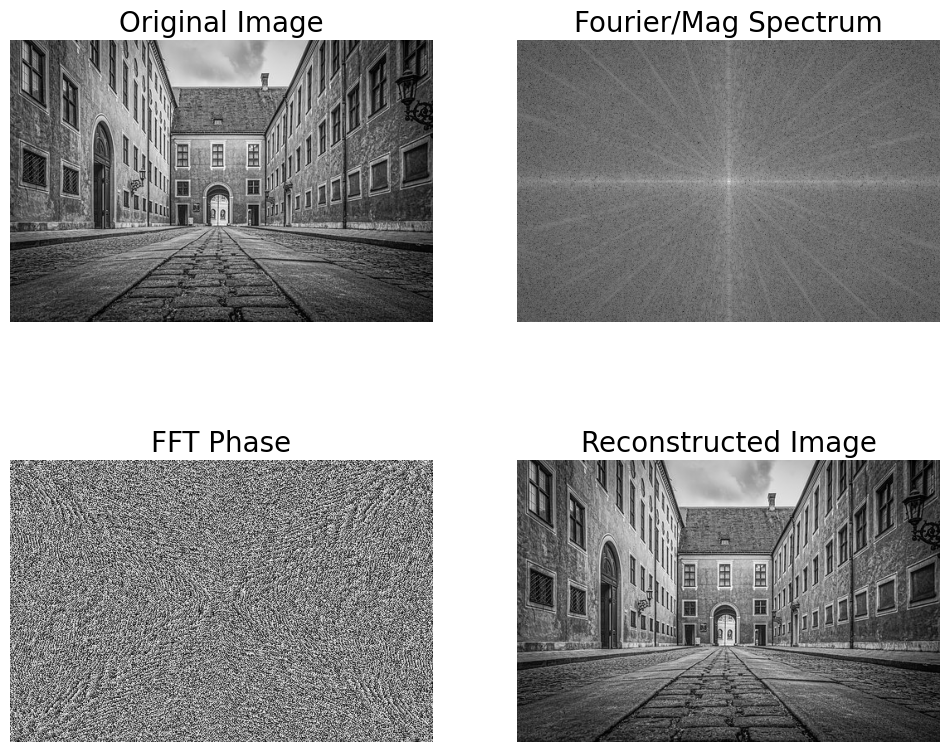

In [8]:
import numpy.fft as fp
from skimage.color import rgb2gray, rgba2rgb

img1 = imread('house.png')
if img1.shape[-1] == 4:  # Check if the image has an alpha channel (RGBA)
    img1 = rgba2rgb(img1) # Convert RGBA to RGB
img1 = rgb2gray(img1)

freq1 = fp.fft2(img1)
iminv1 = fp.ifft2(freq1).real

shiftfreq1 = fp.fftshift(freq1)
proj1 = 20*np.log10(0.01 + np.abs(shiftfreq1))

plt.gray()
plt.figure(figsize=(12,10))

plt.subplot(2,2,1), plot_image(img1, 'Original Image')
plt.subplot(2,2,2), plot_image(proj1, 'Fourier/Mag Spectrum')
plt.subplot(2,2,3), plot_image(np.angle(shiftfreq1),'FFT Phase')
plt.subplot(2,2,4), plot_image(np.clip(iminv1,0,255), 'Reconstructed Image')

plt.show()

<Figure size 640x480 with 0 Axes>

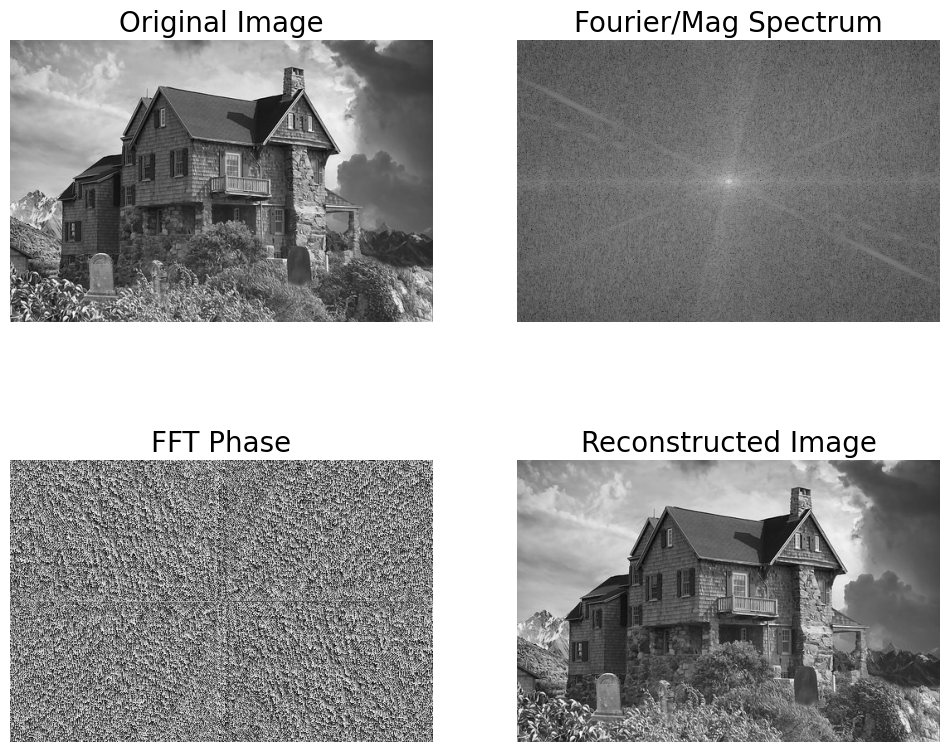

In [9]:
import numpy.fft as fp

img2 = imread('house2.png')
if img2.shape[-1] == 4:  # Check if the image has an alpha channel (RGBA)
    img2 = rgba2rgb(img2) # Convert RGBA to RGB
img2 = rgb2gray(img2)

freq2 = fp.fft2(img2)
iminv2 = fp.ifft2(freq2).real

shiftfreq2 = fp.fftshift(freq2)
proj2 = 20*np.log10(0.01 + np.abs(shiftfreq2))

plt.gray()
plt.figure(figsize=(12,10))

plt.subplot(2,2,1), plot_image(img2, 'Original Image')
plt.subplot(2,2,2), plot_image(proj2, 'Fourier/Mag Spectrum')
plt.subplot(2,2,3), plot_image(np.angle(shiftfreq2),'FFT Phase')
plt.subplot(2,2,4), plot_image(np.clip(iminv2,0,255), 'Reconstructed Image')

plt.show()

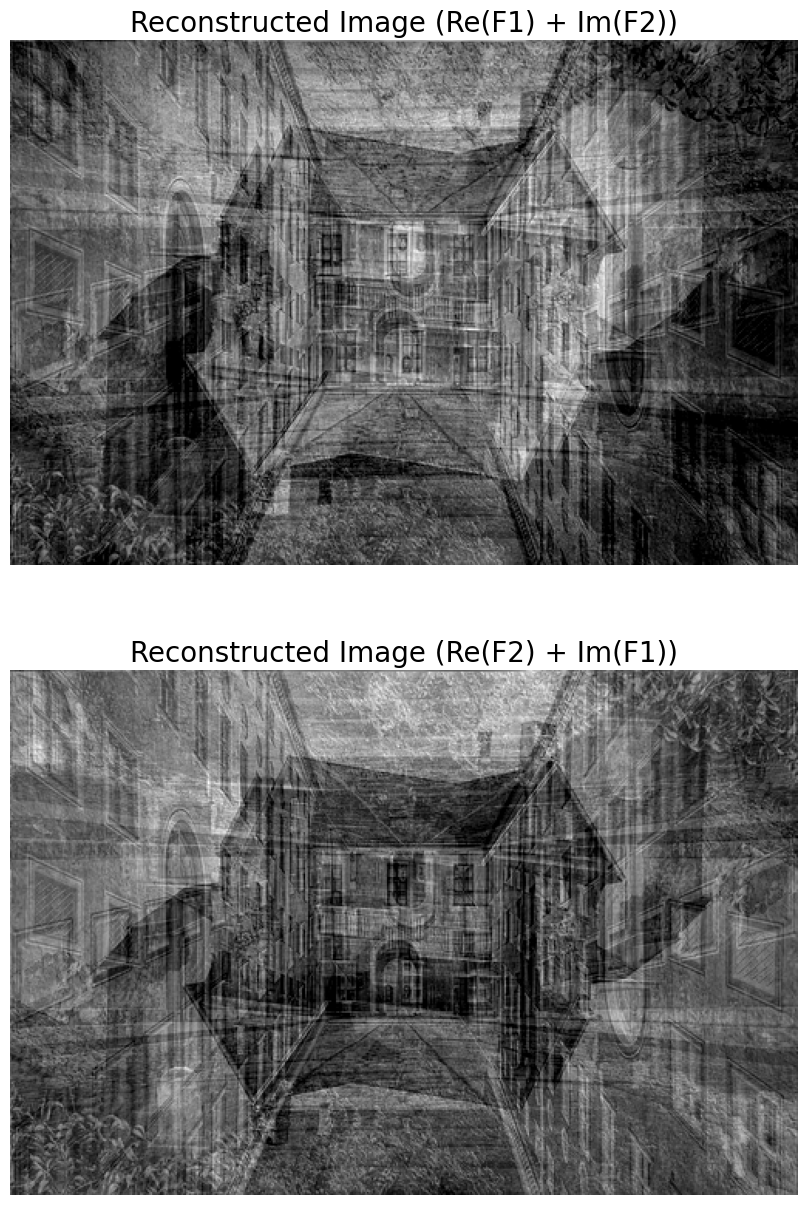

In [10]:
plt.figure(figsize=(20,15))

im1_ = fp.ifft2(np.vectorize(complex)(freq1.real, freq2.imag)).real
im2_ = fp.ifft2(np.vectorize(complex)(freq2.real, freq1.imag)).real

plt.subplot(211)
plot_image(np.clip(im1_,0,255), 'Reconstructed Image (Re(F1) + Im(F2))')

plt.subplot(212)
plot_image(np.clip(im2_,0,255), 'Reconstructed Image (Re(F2) + Im(F1))')

plt.show()